# 06 — Spatial / Regional Analysis

**Per PID Scope of Work item 4 ("Dashboard & Visualization") + Scope of Work item 3 ("derive actionable investment insights"):** map renewable resource potential and the commissioned/planned project pipeline at the oblast (regional) level.

Data sources for the regional layer:
- Wind technical potential by oblast — Uzbekistan Renewable Energy Development report (CAREC 2024).
- Solar irradiance by oblast — Global Solar Atlas + IEA Solar Roadmap.
- Commissioned & under-construction projects 2023–2026 — Ministry of Energy press releases, Enerdata, news.

This notebook produces a static matplotlib map + an interactive Folium HTML map embedded in the dashboard.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import folium
from folium.plugins import MarkerCluster

OUT = Path('../outputs'); OUT.mkdir(exist_ok=True)
DATA = Path('../data/processed')

# Hand-coded oblast atlas — centroids (lat/lon), resource potential, commissioned RE
# Sources: CAREC RE Development report 2024, Global Solar Atlas, MoE press releases 2023-2026
oblasts = pd.DataFrame([
    # oblast,                       lat,    lon,    solar_GHI, wind_pot_TWh, solar_mw, wind_mw, hydro_mw, key_projects
    {'oblast':'Karakalpakstan',     'lat':43.7,'lon':59.0,'solar_ghi':1700,'wind_pot':4.4,'solar_mw':1100,'wind_mw':1600,'hydro_mw':0,    'projects':'4 wind farms 1.6 GW (2026, ACWA); 500 MW solar (Total Eren)'},
    {'oblast':'Bukhara',            'lat':39.8,'lon':64.4,'solar_ghi':1830,'wind_pot':1.0,'solar_mw':1300,'wind_mw':1000,'hydro_mw':0,    'projects':'2 wind 500 MW each Peshku/Gijduvan (2025); 250 MW solar'},
    {'oblast':'Navoi',              'lat':40.1,'lon':65.4,'solar_ghi':1850,'wind_pot':2.9,'solar_mw':800, 'wind_mw':300, 'hydro_mw':0,    'projects':'Tomdi solar 100 MW; Zarafshan wind 500 MW (PRC investment)'},
    {'oblast':'Kashkadarya',        'lat':38.9,'lon':65.8,'solar_ghi':1830,'wind_pot':0.5,'solar_mw':900, 'wind_mw':100, 'hydro_mw':80,   'projects':'Guzar 300 MW solar + 75 MWh BESS (Masdar, 2026 FC)'},
    {'oblast':'Surkhandarya',       'lat':37.9,'lon':67.4,'solar_ghi':1820,'wind_pot':0.2,'solar_mw':500, 'wind_mw':0,   'hydro_mw':200,  'projects':'Sherabad 200 MW solar (2023)'},
    {'oblast':'Samarkand',          'lat':39.7,'lon':66.9,'solar_ghi':1750,'wind_pot':0.3,'solar_mw':1000,'wind_mw':0,   'hydro_mw':120,  'projects':'2× 500 MW solar + 334 MW BESS (ACWA, planned)'},
    {'oblast':'Jizzakh',            'lat':40.1,'lon':67.8,'solar_ghi':1740,'wind_pot':0.4,'solar_mw':600, 'wind_mw':0,   'hydro_mw':50,   'projects':'Gallaorol solar 100 MW (2024); SMR construction site'},
    {'oblast':'Tashkent',           'lat':41.3,'lon':69.3,'solar_ghi':1640,'wind_pot':0.2,'solar_mw':400, 'wind_mw':0,   'hydro_mw':900,  'projects':'Y. Chirchik solar 100 MW; Charvak hydro upgrade'},
    {'oblast':'Namangan',           'lat':41.0,'lon':71.7,'solar_ghi':1620,'wind_pot':0.1,'solar_mw':200, 'wind_mw':0,   'hydro_mw':350,  'projects':'Solar 200 MW (2024); hydro modernisation'},
    {'oblast':'Fergana',            'lat':40.4,'lon':71.8,'solar_ghi':1620,'wind_pot':0.1,'solar_mw':150, 'wind_mw':0,   'hydro_mw':200,  'projects':'Industrial PV portfolio'},
    {'oblast':'Andijan',            'lat':40.8,'lon':72.3,'solar_ghi':1630,'wind_pot':0.1,'solar_mw':100, 'wind_mw':0,   'hydro_mw':30,   'projects':'Pilot rooftop programs'},
    {'oblast':'Khorezm',            'lat':41.5,'lon':60.6,'solar_ghi':1720,'wind_pot':0.7,'solar_mw':150, 'wind_mw':100, 'hydro_mw':0,    'projects':'Tuyamuyun hybrid hydro+solar pilot'},
    {'oblast':'Syrdarya',           'lat':40.5,'lon':68.7,'solar_ghi':1700,'wind_pot':0.1,'solar_mw':80,  'wind_mw':0,   'hydro_mw':0,    'projects':'Small distributed PV'},
])
oblasts['total_re_mw'] = oblasts['solar_mw'] + oblasts['wind_mw'] + oblasts['hydro_mw']
oblasts['dominant'] = oblasts[['solar_mw','wind_mw','hydro_mw']].idxmax(axis=1).str.replace('_mw','')
oblasts.to_csv(DATA/'oblast_atlas.csv', index=False)
print(f'{len(oblasts)} oblasts mapped, total RE MW = {oblasts.total_re_mw.sum():,}')
oblasts[['oblast','solar_ghi','wind_pot','total_re_mw','dominant']]

13 oblasts mapped, total RE MW = 12,310


,oblast,solar_ghi,wind_pot,total_re_mw,dominant
0,Karakalpakstan,1700,4.4,2700,wind
1,Bukhara,1830,1.0,2300,solar
2,Navoi,1850,2.9,1100,solar
3,Kashkadarya,1830,0.5,1080,solar
4,Surkhandarya,1820,0.2,700,solar
5,Samarkand,1750,0.3,1120,solar
6,Jizzakh,1740,0.4,650,solar
7,Tashkent,1640,0.2,1300,hydro
8,Namangan,1620,0.1,550,hydro
9,Fergana,1620,0.1,350,hydro


## Static map — solar irradiance & RE capacity by oblast

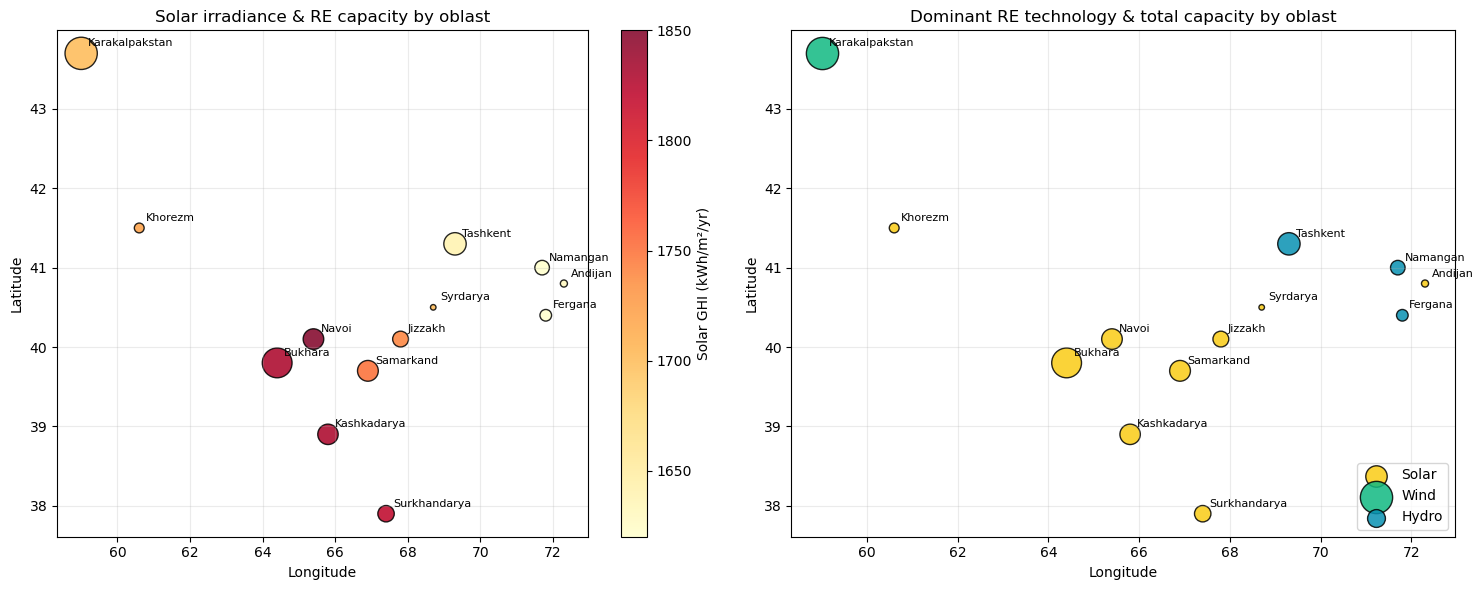

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
tech_colors = {'solar':'#facc15','wind':'#10b981','hydro':'#0891b2'}

# Panel 1: solar irradiance (color) + total RE (size)
ax = axes[0]
sc = ax.scatter(oblasts['lon'], oblasts['lat'], s=oblasts['total_re_mw']/5,
                 c=oblasts['solar_ghi'], cmap='YlOrRd', alpha=0.85, edgecolors='black')
for _, r in oblasts.iterrows():
    ax.annotate(r['oblast'], (r['lon'], r['lat']), fontsize=8, xytext=(5,5), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Solar GHI (kWh/m²/yr)')
ax.set_title('Solar irradiance & RE capacity by oblast'); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(alpha=0.25)

# Panel 2: tech-dominant by oblast (color) + capacity (size)
ax = axes[1]
for tech, color in tech_colors.items():
    sub = oblasts[oblasts['dominant']==tech]
    ax.scatter(sub['lon'], sub['lat'], s=sub['total_re_mw']/5, c=color, alpha=0.85,
                edgecolors='black', label=tech.title())
for _, r in oblasts.iterrows():
    ax.annotate(r['oblast'], (r['lon'], r['lat']), fontsize=8, xytext=(5,5), textcoords='offset points')
ax.set_title('Dominant RE technology & total capacity by oblast'); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower right'); ax.grid(alpha=0.25)

plt.tight_layout(); plt.savefig(DATA/'spatial_oblast_static.png', dpi=140, bbox_inches='tight'); plt.show()

## Interactive Folium map

In [3]:
m = folium.Map(location=[41.5, 64.5], zoom_start=6, tiles='cartodbpositron')

for _, r in oblasts.iterrows():
    color = tech_colors[r['dominant']]
    radius = max(8, r['total_re_mw']/120)
    popup = folium.Popup(f"""
    <b>{r['oblast']}</b><br>
    Solar GHI: {r['solar_ghi']} kWh/m²/yr<br>
    Wind tech. potential: {r['wind_pot']} TWh/yr<br>
    Installed: solar {r['solar_mw']:,} MW · wind {r['wind_mw']:,} MW · hydro {r['hydro_mw']:,} MW<br>
    Key projects: {r['projects']}
    """, max_width=320)
    folium.CircleMarker(location=[r['lat'], r['lon']], radius=radius,
                         popup=popup, tooltip=f"{r['oblast']} ({r['total_re_mw']:,} MW)",
                         color='black', weight=1, fillColor=color, fillOpacity=0.75).add_to(m)

# Legend
legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;width:200px;background:white;
            border:2px solid #333;border-radius:6px;padding:10px;font-size:12px;z-index:1000">
<b>Dominant RE technology</b><br>
<span style="color:#facc15;">●</span> Solar<br>
<span style="color:#10b981;">●</span> Wind<br>
<span style="color:#0891b2;">●</span> Hydro<br>
<em>Bubble size ∝ total capacity (MW)</em>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

out_html = OUT/'uzbekistan_renewable_map.html'
m.save(str(out_html))
print(f'Saved → {out_html}')
m

Saved → ../outputs/uzbekistan_renewable_map.html


## Spatial findings (for ILF advisory)

1. **Wind concentration** — Karakalpakstan + Navoi + Bukhara hold ~84% of the country's wind technical potential. ACWA Power's 2025–2026 build-out is already in these three oblasts.
2. **Solar belt** — Bukhara, Kashkadarya, Surkhandarya, Navoi share GHI > 1,800 kWh/m²/yr — competitive with Saudi Arabia.
3. **Hydro is in the east** — Tashkent (Charvak) + Fergana valley account for ~75% of hydro capacity; modernisation rather than new build.
4. **Grid corridor risk** — most new RE is in the west; Tashkent demand centre is in the east. 1,450 km of new HV lines (ACWA's Karakalpakstan project) is the binding constraint.
5. **Plan B nuclear site** — Jizzakh oblast (SMR construction begun, 2024). Near major demand centre → minimal new transmission needed.